In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

In [42]:
longi = pd.read_csv('oasis_longitudinal.csv')
cross = pd.read_csv('oasis_cross-sectional.csv')

longi['SES'] = longi['SES'].fillna(longi['SES'].median())
longi['MMSE'] = longi['MMSE'].fillna(longi['MMSE'].median())
longi['MMSE'] = longi['MMSE'].fillna(longi['MMSE'].median())
cross['SES'] = cross['SES'].fillna(cross['SES'].median())
cross['MMSE'] = cross['MMSE'].fillna(cross['MMSE'].median())
cross['Educ'] = cross['Educ'].fillna(cross['Educ'].median())
cross['CDR'] = cross['CDR'].fillna(cross['CDR'].median())

cross_renamed = cross.rename(columns={'Educ': 'EDUC'})

features = ['Sex', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X_longi = longi[features].fillna(longi.median(numeric_only=True))
y_longi = longi['CDR'].astype(str)
X_cross = cross_renamed[features].fillna(longi.median(numeric_only=True))
y_cross = cross_renamed['CDR'].astype(str)

clases_str = ['0.0', '0.5', '1.0', '2.0']
longi.isna().sum()

Subject ID    0
MRI ID        0
Group         0
Visit         0
MR Delay      0
Sex           0
Hand          0
Age           0
EDUC          0
SES           0
MMSE          0
CDR           0
eTIV          0
nWBV          0
ASF           0
dtype: int64

In [47]:
columnas_comunes = ['ID', 'Sex', 'Age', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF']
longi_renamed = longi.rename(columns={'EDUC': 'Educ', 'Subject ID': 'ID'})
df = pd.concat([cross[columnas_comunes], longi_renamed[columnas_comunes]], ignore_index=True)
features_df = ['Sex', 'Age', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
Xdf = df[features_df].fillna(longi.median(numeric_only=True))
ydf = df['CDR'].astype(str)
df.isna().sum()
df.describe()

,Sex,Age,SES,MMSE,CDR,eTIV,nWBV,ASF
count,809.000000,809.000000,809.000000,809.000000,809.000000,809.000000,809.000000,809.000000
mean,0.405439,63.186650,2.332509,27.677379,0.216934,1484.782447,0.763037,1.197311
std,0.491280,23.117511,0.970834,3.281888,0.350350,166.911689,0.059401,0.133031
min,0.000000,18.000000,1.000000,4.000000,0.000000,1106.000000,0.644000,0.876000
25%,0.000000,49.000000,2.000000,27.000000,0.000000,1361.000000,0.715000,1.108000
50%,0.000000,72.000000,2.000000,29.000000,0.000000,1475.000000,0.754000,1.190000
75%,1.000000,80.000000,3.000000,29.000000,0.500000,1583.000000,0.817000,1.290000
max,1.000000,98.000000,5.000000,30.000000,2.000000,2004.000000,0.893000,1.587000


Buscando el k óptimo...


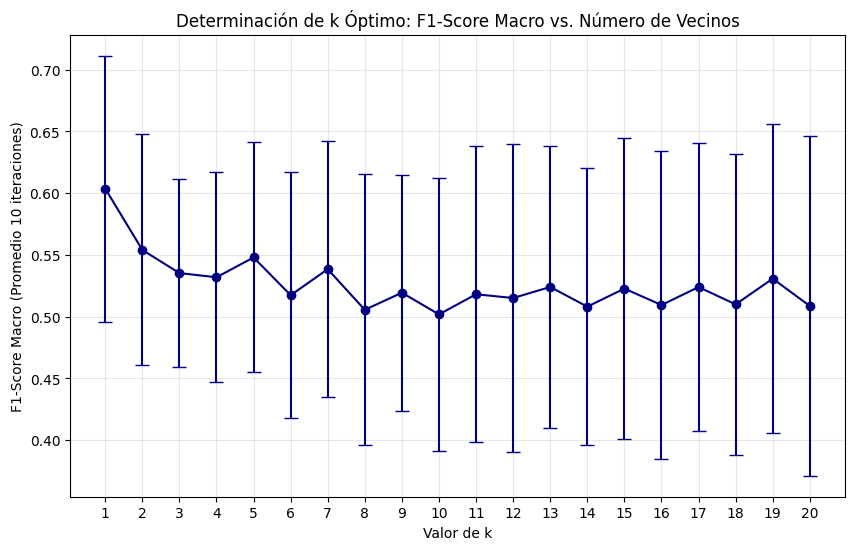

El valor de k con mejor desempeño promedio es: 1


In [43]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_longi)

# 2. Evaluación de k (1 a 20) según la Guía [1]
k_values = range(1, 21)
mean_f1_scores = []
std_f1_scores = []

print("Buscando el k óptimo...")

for k in k_values:
    iter_f1 = []
    # 10 Validaciones independientes 80/20 [6]
    for i in range(10):
        X_train, X_test, y_train, y_test = train_test_split(
            X_imputed, y_longi, test_size=0.2, random_state=i
        )
        
        # Escalamiento Z-score (Obligatorio para KNN) [7, 8]
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)
        
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_s, y_train)
        y_pred = knn.predict(X_test_s)
        
        iter_f1.append(f1_score(y_test, y_pred, average='macro', zero_division=0))
    
    mean_f1_scores.append(np.mean(iter_f1))
    std_f1_scores.append(np.std(iter_f1))

# 3. Visualización del Desempeño vs k
plt.figure(figsize=(10, 6))
plt.errorbar(k_values, mean_f1_scores, yerr=std_f1_scores, fmt='-o', color='navy', capsize=5)
plt.title("Determinación de k Óptimo: F1-Score Macro vs. Número de Vecinos")
plt.xlabel("Valor de k")
plt.ylabel("F1-Score Macro (Promedio 10 iteraciones)")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

# Identificar el mejor k
best_k = k_values[np.argmax(mean_f1_scores)]
print(f"El valor de k con mejor desempeño promedio es: {best_k}")

Buscando el k óptimo...


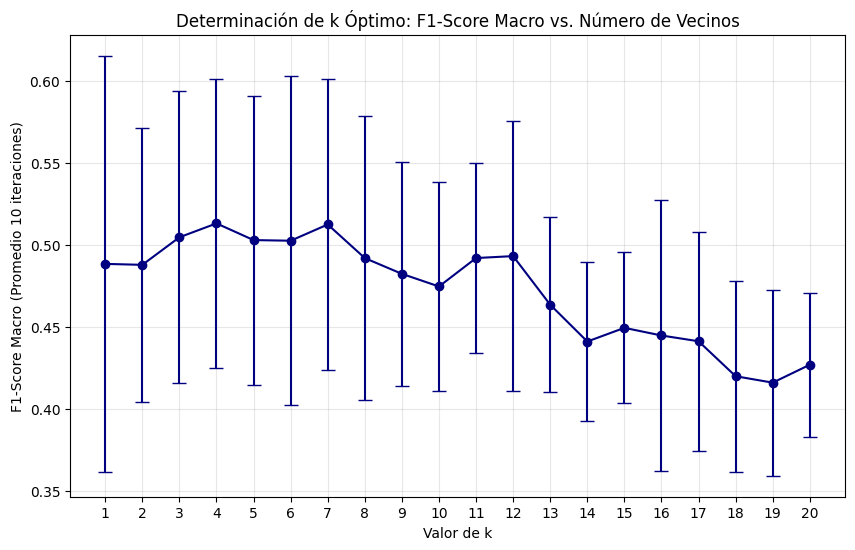

El valor de k con mejor desempeño promedio es: 4


In [44]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_cross)

# 2. Evaluación de k (1 a 20) según la Guía [1]
k_values = range(1, 21)
mean_f1_scores = []
std_f1_scores = []

print("Buscando el k óptimo...")

for k in k_values:
    iter_f1 = []
    # 10 Validaciones independientes 80/20 [6]
    for i in range(10):
        X_train, X_test, y_train, y_test = train_test_split(
            X_imputed, y_cross, test_size=0.2, random_state=i
        )
        
        # Escalamiento Z-score (Obligatorio para KNN) [7, 8]
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)
        
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_s, y_train)
        y_pred = knn.predict(X_test_s)
        
        iter_f1.append(f1_score(y_test, y_pred, average='macro', zero_division=0))
    
    mean_f1_scores.append(np.mean(iter_f1))
    std_f1_scores.append(np.std(iter_f1))

# 3. Visualización del Desempeño vs k
plt.figure(figsize=(10, 6))
plt.errorbar(k_values, mean_f1_scores, yerr=std_f1_scores, fmt='-o', color='navy', capsize=5)
plt.title("Determinación de k Óptimo: F1-Score Macro vs. Número de Vecinos")
plt.xlabel("Valor de k")
plt.ylabel("F1-Score Macro (Promedio 10 iteraciones)")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

# Identificar el mejor k
best_k = k_values[np.argmax(mean_f1_scores)]
print(f"El valor de k con mejor desempeño promedio es: {best_k}")

Buscando el k óptimo...


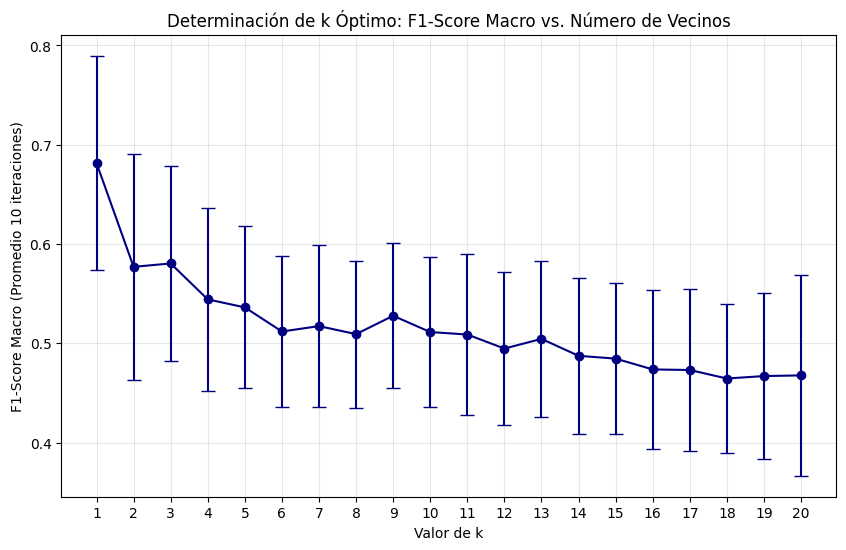

El valor de k con mejor desempeño promedio es: 1


In [45]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(Xdf)

# 2. Evaluación de k (1 a 20) según la Guía [1]
k_values = range(1, 21)
mean_f1_scores = []
std_f1_scores = []

print("Buscando el k óptimo...")

for k in k_values:
    iter_f1 = []
    # 10 Validaciones independientes 80/20 [6]
    for i in range(10):
        X_train, X_test, y_train, y_test = train_test_split(
            X_imputed, ydf, test_size=0.2, random_state=i
        )
        
        # Escalamiento Z-score (Obligatorio para KNN) [7, 8]
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)
        
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_s, y_train)
        y_pred = knn.predict(X_test_s)
        
        iter_f1.append(f1_score(y_test, y_pred, average='macro', zero_division=0))
    
    mean_f1_scores.append(np.mean(iter_f1))
    std_f1_scores.append(np.std(iter_f1))

# 3. Visualización del Desempeño vs k
plt.figure(figsize=(10, 6))
plt.errorbar(k_values, mean_f1_scores, yerr=std_f1_scores, fmt='-o', color='navy', capsize=5)
plt.title("Determinación de k Óptimo: F1-Score Macro vs. Número de Vecinos")
plt.xlabel("Valor de k")
plt.ylabel("F1-Score Macro (Promedio 10 iteraciones)")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.show()

# Identificar el mejor k
best_k = k_values[np.argmax(mean_f1_scores)]
print(f"El valor de k con mejor desempeño promedio es: {best_k}")

In [ ]:
# Carga del set longitudinal (373 ejemplos)
# Mapeo a clases binarias: 0 = No Demente, 1 = Demente (CDR >= 0.5)
df['Binary_Target'] = df['CDR'].apply(lambda x: 1 if x >= 0.5 else 0)

# Selección de atributos según el informe_2
features = ['Sex', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = df[features]
y = df['Binary_Target']

# Tratamiento de datos faltantes en SES y MMSE [2, 5]
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

print(f"Distribución binaria: {df['Binary_Target'].value_counts().to_dict()}")

# Diccionario para almacenar métricas
metrics_bin = {'acc': [], 'prec': [], 'rec': [], 'f1': []}

for i in range(10):
    # Partición 80% entrenamiento / 20% prueba
    X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.2, random_state=i)
    
    # Escalamiento: Se ajusta en entreno y se aplica en prueba para evitar filtración [7]
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # Modelo KNN (usando k=5 como referencia estable) [8]
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_s, y_train)
    y_pred = knn.predict(X_test_s)
    
    # Registro de métricas
    metrics_bin['acc'].append(accuracy_score(y_test, y_pred))
    metrics_bin['prec'].append(precision_score(y_test, y_pred))
    metrics_bin['rec'].append(recall_score(y_test, y_pred))
    metrics_bin['f1'].append(f1_score(y_test, y_pred))

# Reporte de resultados finales (Media ± DE)
print("\n--- RESULTADOS MODELO BINARIO (Media ± DE) ---")
for m, vals in metrics_bin.items():
    print(f"{m.capitalize()}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

Distribución binaria: {0: 206, 1: 167}

--- RESULTADOS MODELO BINARIO (Media ± DE) ---
Acc: 0.7707 ± 0.0404
Prec: 0.8042 ± 0.0547
Rec: 0.6618 ± 0.0882
F1: 0.7210 ± 0.0508


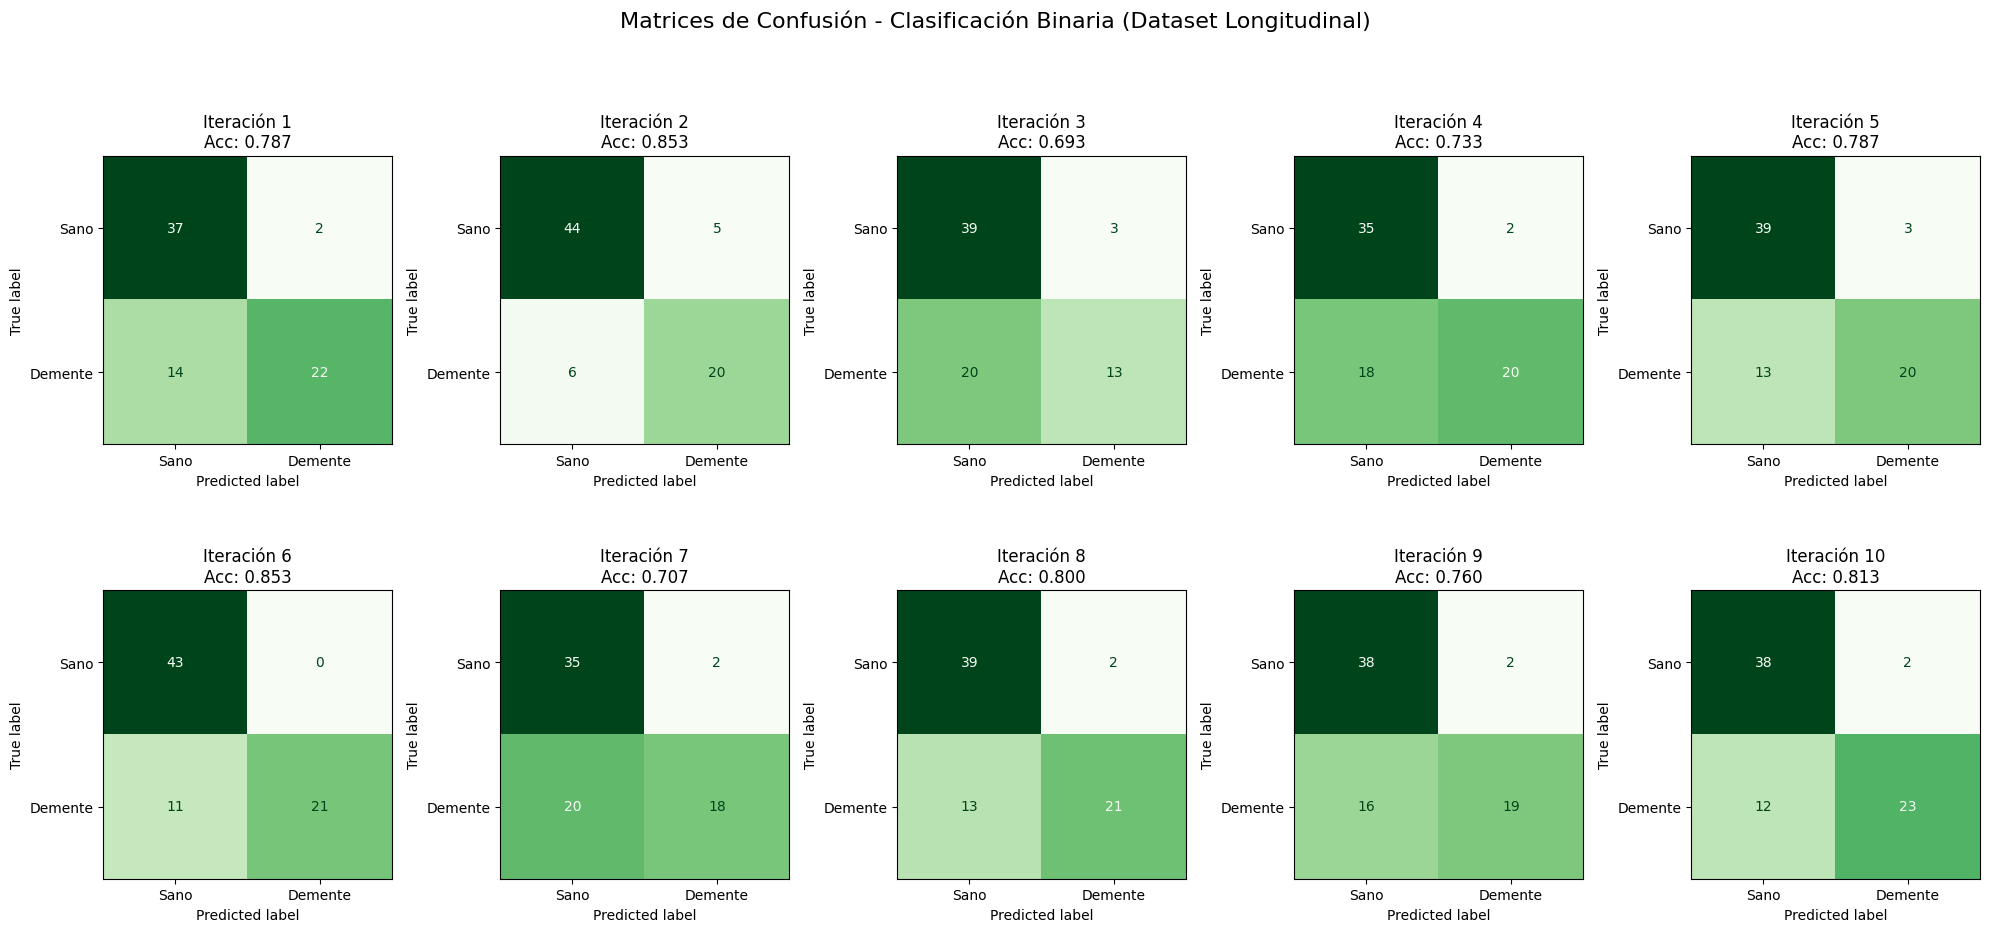

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

# 4. Diseño Experimental: 10 Validaciones Independientes 80/20 [8]
for i in range(10):
    # Partición aleatoria independiente
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y, test_size=0.2, random_state=i
    )
    
    # Escalamiento: Ajustado en entreno y aplicado en prueba [7]
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # Modelo KNN con k=5 [9]
    knn = KNeighborsClassifier(n_neighbors=4)
    knn.fit(X_train_s, y_train)
    y_pred = knn.predict(X_test_s)
    
    # Generación y visualización de la matriz en el grid
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sano', 'Demente'])
    disp.plot(ax=axes[i], cmap='Greens', colorbar=False)
    
    # Título por iteración con Accuracy individual
    acc_iter = (y_pred == y_test).mean()
    axes[i].set_title(f"Iteración {i+1}\nAcc: {acc_iter:.3f}")

plt.suptitle("Matrices de Confusión - Clasificación Binaria (Dataset Longitudinal)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Iniciando validaciones independientes...


/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is pre

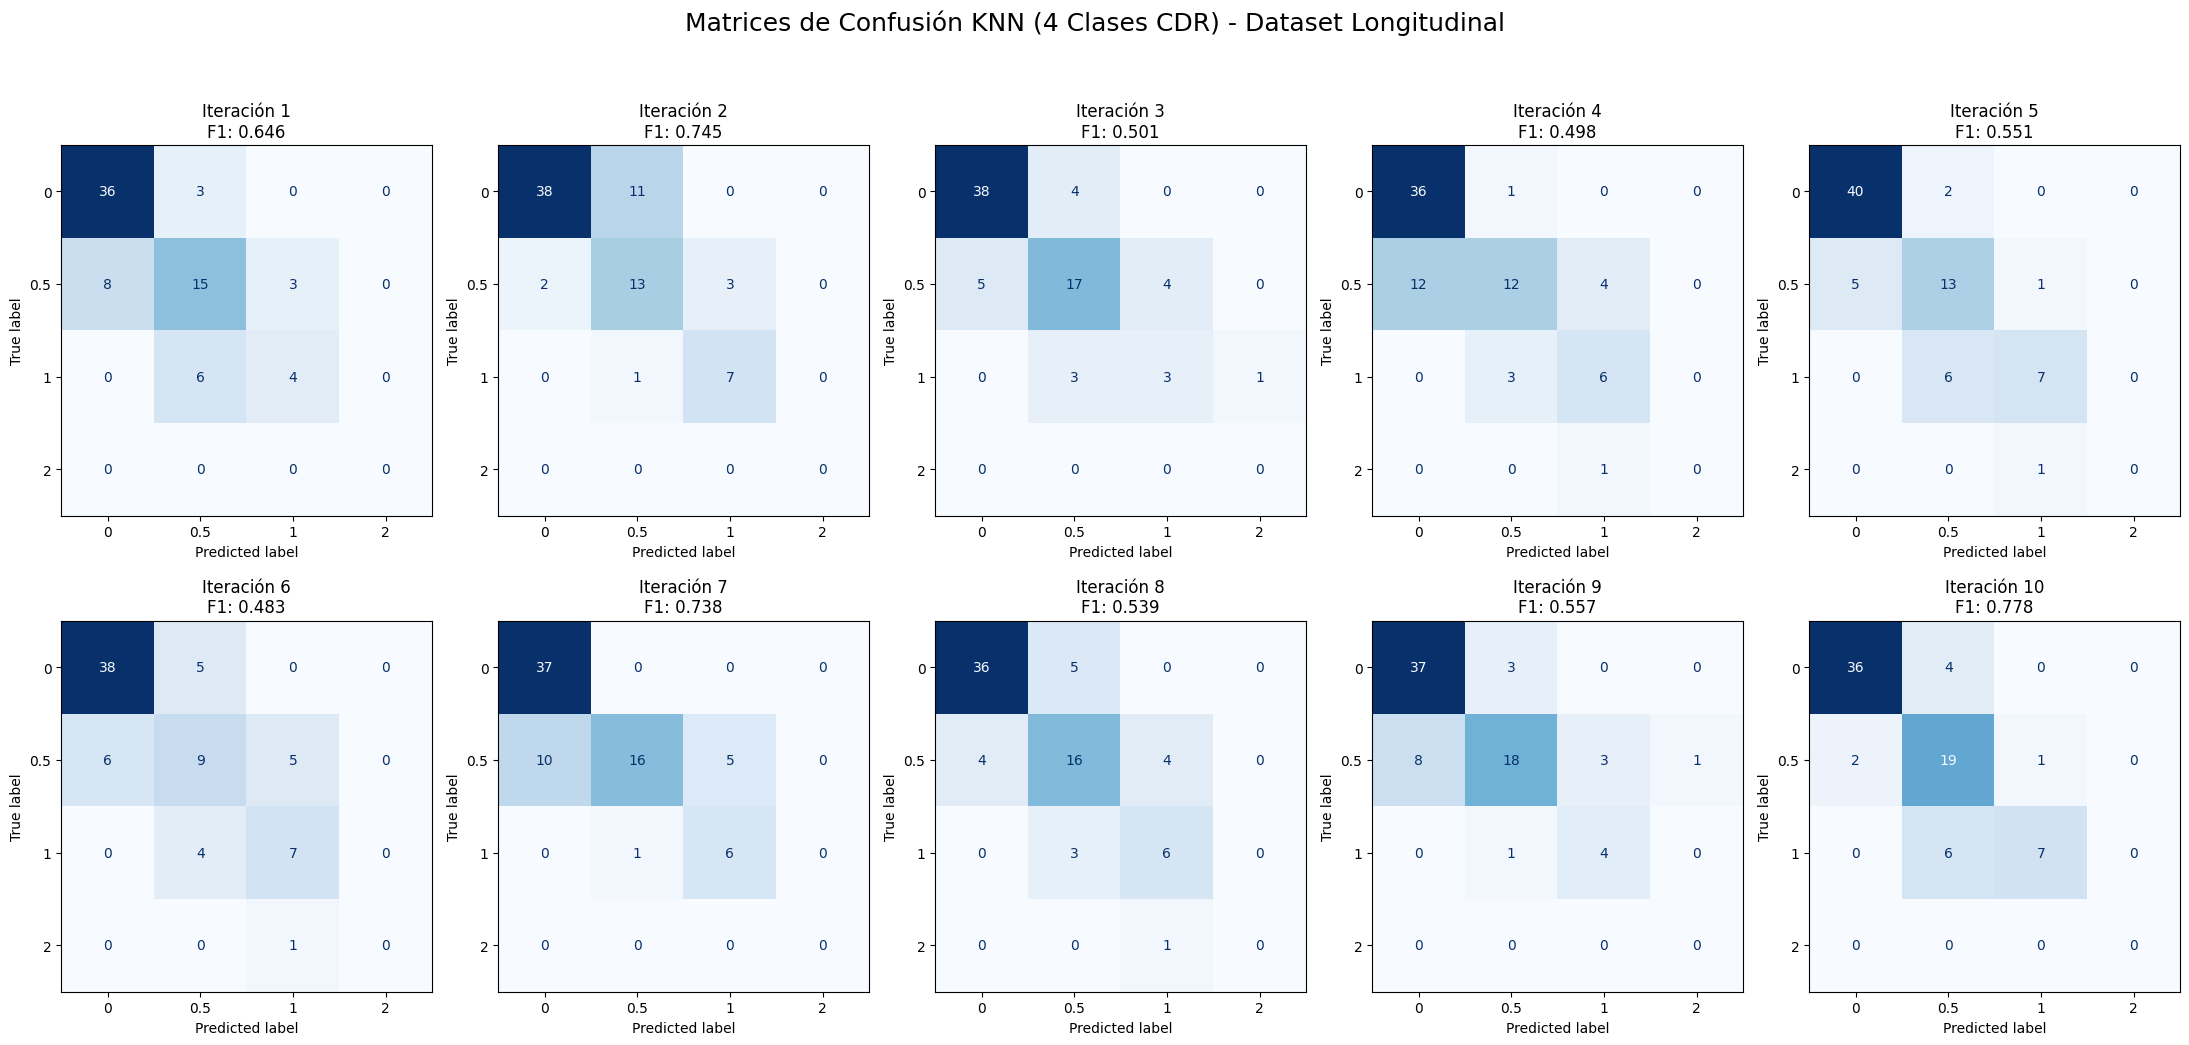


Métrica                   | Promedio ± DE            
-------------------------------------------------------
Accuracy                  | 0.7693 ± 0.0332
Precision (Macro)         | 0.6123 ± 0.1163
Recall (Macro)            | 0.6167 ± 0.1158
F1-score (Macro)          | 0.6037 ± 0.1077
AUC (Macro)               | 0.7133 ± 0.0188


In [35]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_longi)

# 2. Configuración Experimental (10 Validaciones 80/20)
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
fig, axes = plt.subplots(2, 5, figsize=(22, 11))
axes = axes.flatten()

print("Iniciando validaciones independientes...")

for i in range(10):
    # Partición aleatoria 80/20 única por iteración [2]
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y_longi, test_size=0.2, random_state=i
    )
    
    # 3. Escalamiento: Obligatorio para KNN (Sección 11.1 de la guía) [1, 3]
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # 4. Entrenamiento Modelo KNN (k=5 como base)
    knn = KNeighborsClassifier(n_neighbors=1)
    knn.fit(X_train_s, y_train)
    y_pred = knn.predict(X_test_s)
    y_proba = knn.predict_proba(X_test_s) # Necesario para AUC
    
    # 5. Registro de Métricas (Promedio Macro por desbalance) [4, 5]
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
    results['rec'].append(recall_score(y_test, y_pred, average='macro', zero_division=0))
    results['f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))
    
    # Cálculo de AUC Multiclase (One-vs-Rest)
    # Binarizamos y_test usando las etiquetas de texto
    y_test_bin = label_binarize(y_test, classes=clases_str)
    try:
        results['auc'].append(roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro'))
    except ValueError:
        results['auc'].append(np.nan) # Manejo si una clase no aparece en el set de prueba
    
    # 6. Generación del Grid de Matrices de Confusión
    # Ahora 'y_test', 'y_pred' y 'clases_str' son todos strings, eliminando el TypeError
    cm = confusion_matrix(y_test, y_pred, labels=clases_str)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '0.5', '1', '2'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Iteración {i+1}\nF1: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión KNN (4 Clases CDR) - Dataset Longitudinal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 7. Reporte Final de Desempeño (Media ± DE) [6]
print("\n" + "="*55)
print(f"{'Métrica':<25} | {'Promedio ± DE':<25}")
print("-" * 55)
print(f"{'Accuracy':<25} | {np.mean(results['acc']):.4f} ± {np.std(results['acc']):.4f}")
print(f"{'Precision (Macro)':<25} | {np.mean(results['prec']):.4f} ± {np.std(results['prec']):.4f}")
print(f"{'Recall (Macro)':<25} | {np.mean(results['rec']):.4f} ± {np.std(results['rec']):.4f}")
print(f"{'F1-score (Macro)':<25} | {np.mean(results['f1']):.4f} ± {np.std(results['f1']):.4f}")
print(f"{'AUC (Macro)':<25} | {np.nanmean(results['auc']):.4f} ± {np.nanstd(results['auc']):.4f}")
print("="*55)


Iniciando validaciones independientes...


/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is pre

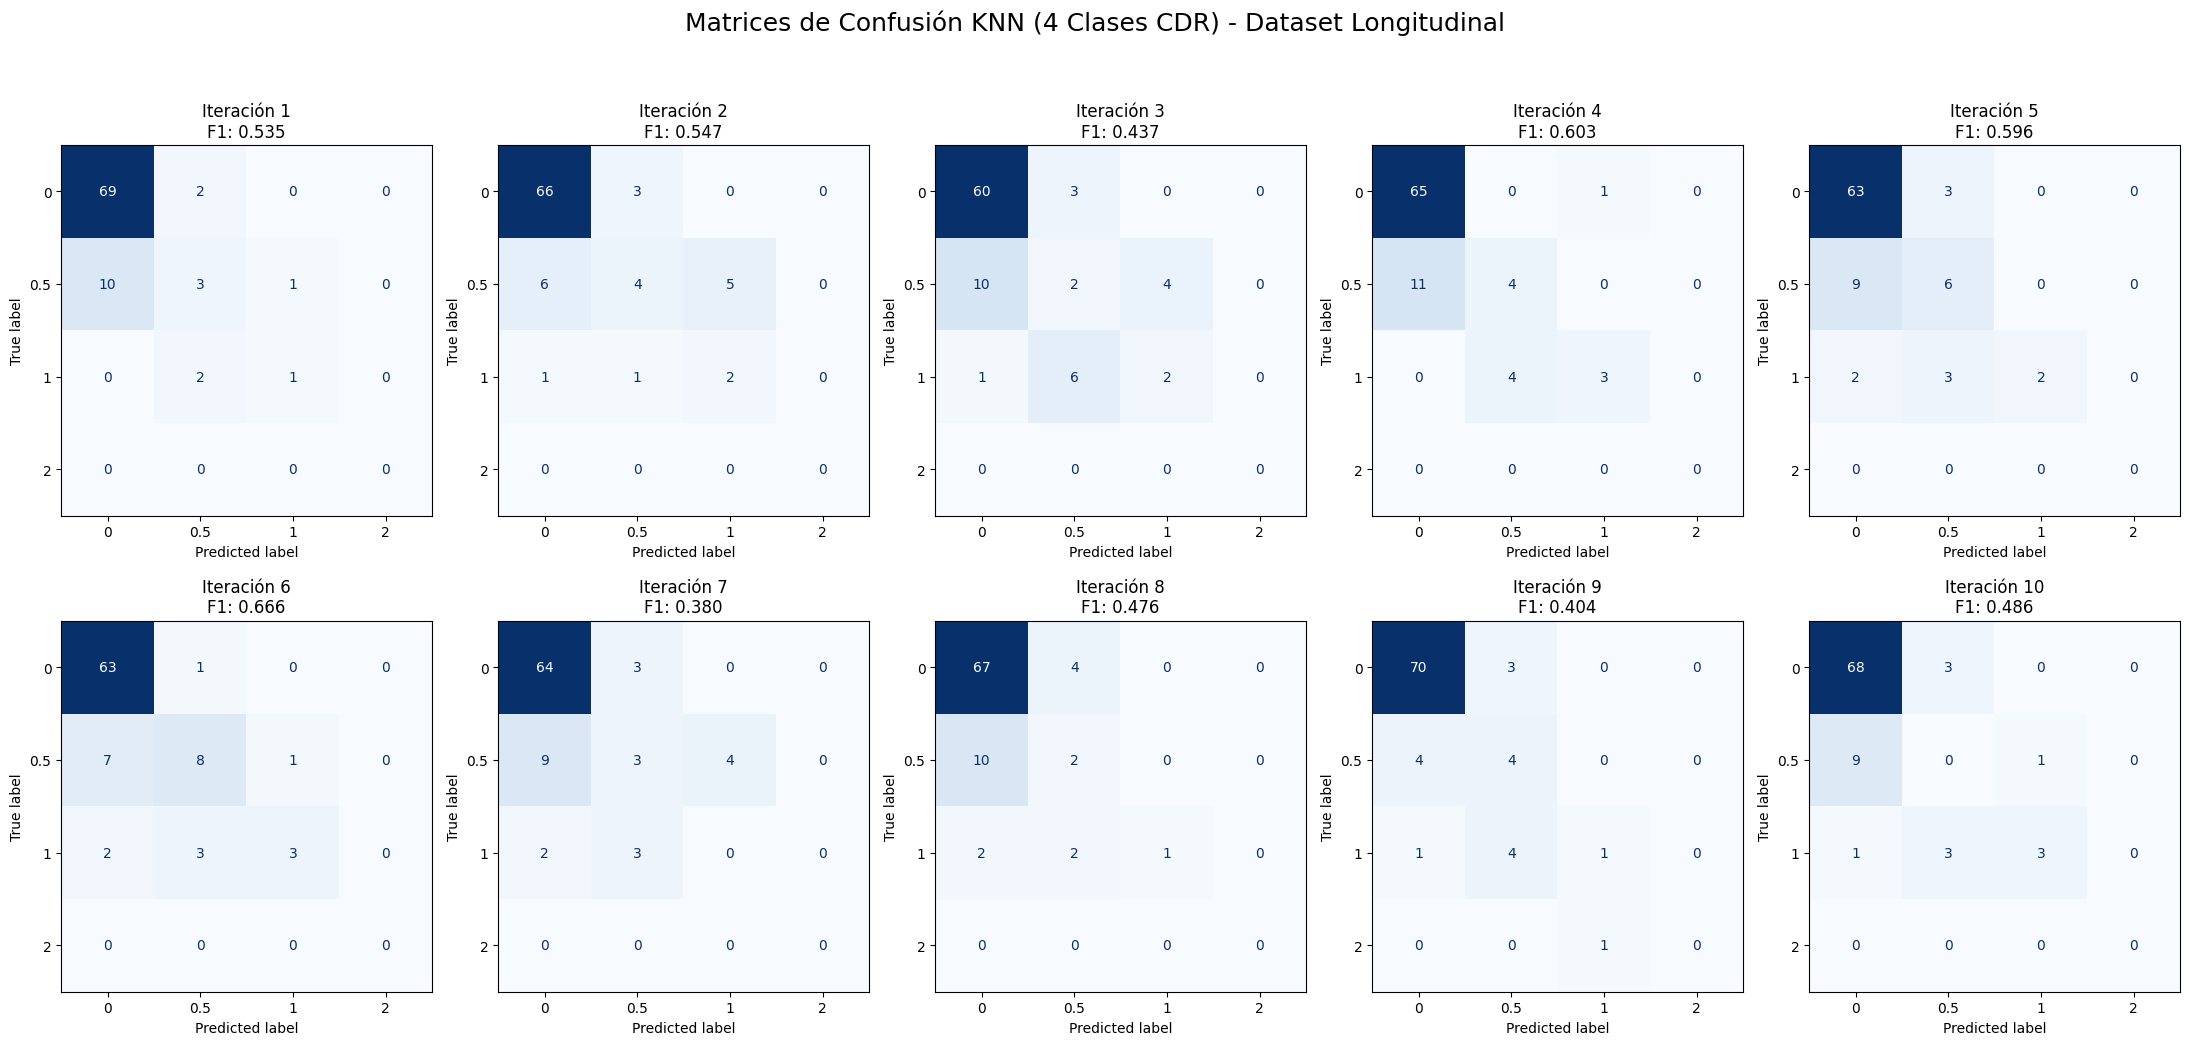


Métrica                   | Promedio ± DE            
-------------------------------------------------------
Accuracy                  | 0.8057 ± 0.0354
Precision (Macro)         | 0.5952 ± 0.1310
Recall (Macro)            | 0.4927 ± 0.0762
F1-score (Macro)          | 0.5131 ± 0.0880
AUC (Macro)               | 0.7876 ± 0.0000


In [48]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_cross)

# 2. Configuración Experimental (10 Validaciones 80/20)
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
fig, axes = plt.subplots(2, 5, figsize=(22, 11))
axes = axes.flatten()

print("Iniciando validaciones independientes...")

for i in range(10):
    # Partición aleatoria 80/20 única por iteración [2]
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y_cross, test_size=0.2, random_state=i
    )
    
    # 3. Escalamiento: Obligatorio para KNN (Sección 11.1 de la guía) [1, 3]
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # 4. Entrenamiento Modelo KNN (k=5 como base)
    knn = KNeighborsClassifier(n_neighbors=4)
    knn.fit(X_train_s, y_train)
    y_pred = knn.predict(X_test_s)
    y_proba = knn.predict_proba(X_test_s) # Necesario para AUC
    
    # 5. Registro de Métricas (Promedio Macro por desbalance) [4, 5]
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
    results['rec'].append(recall_score(y_test, y_pred, average='macro', zero_division=0))
    results['f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))
    
    # Cálculo de AUC Multiclase (One-vs-Rest)
    # Binarizamos y_test usando las etiquetas de texto
    y_test_bin = label_binarize(y_test, classes=clases_str)
    try:
        results['auc'].append(roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro'))
    except ValueError:
        results['auc'].append(np.nan) # Manejo si una clase no aparece en el set de prueba
    
    # 6. Generación del Grid de Matrices de Confusión
    # Ahora 'y_test', 'y_pred' y 'clases_str' son todos strings, eliminando el TypeError
    cm = confusion_matrix(y_test, y_pred, labels=clases_str)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '0.5', '1', '2'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Iteración {i+1}\nF1: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión KNN (4 Clases CDR) - Dataset Longitudinal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 7. Reporte Final de Desempeño (Media ± DE) [6]
print("\n" + "="*55)
print(f"{'Métrica':<25} | {'Promedio ± DE':<25}")
print("-" * 55)
print(f"{'Accuracy':<25} | {np.mean(results['acc']):.4f} ± {np.std(results['acc']):.4f}")
print(f"{'Precision (Macro)':<25} | {np.mean(results['prec']):.4f} ± {np.std(results['prec']):.4f}")
print(f"{'Recall (Macro)':<25} | {np.mean(results['rec']):.4f} ± {np.std(results['rec']):.4f}")
print(f"{'F1-score (Macro)':<25} | {np.mean(results['f1']):.4f} ± {np.std(results['f1']):.4f}")
print(f"{'AUC (Macro)':<25} | {np.nanmean(results['auc']):.4f} ± {np.nanstd(results['auc']):.4f}")
print("="*55)

Iniciando validaciones independientes...


/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


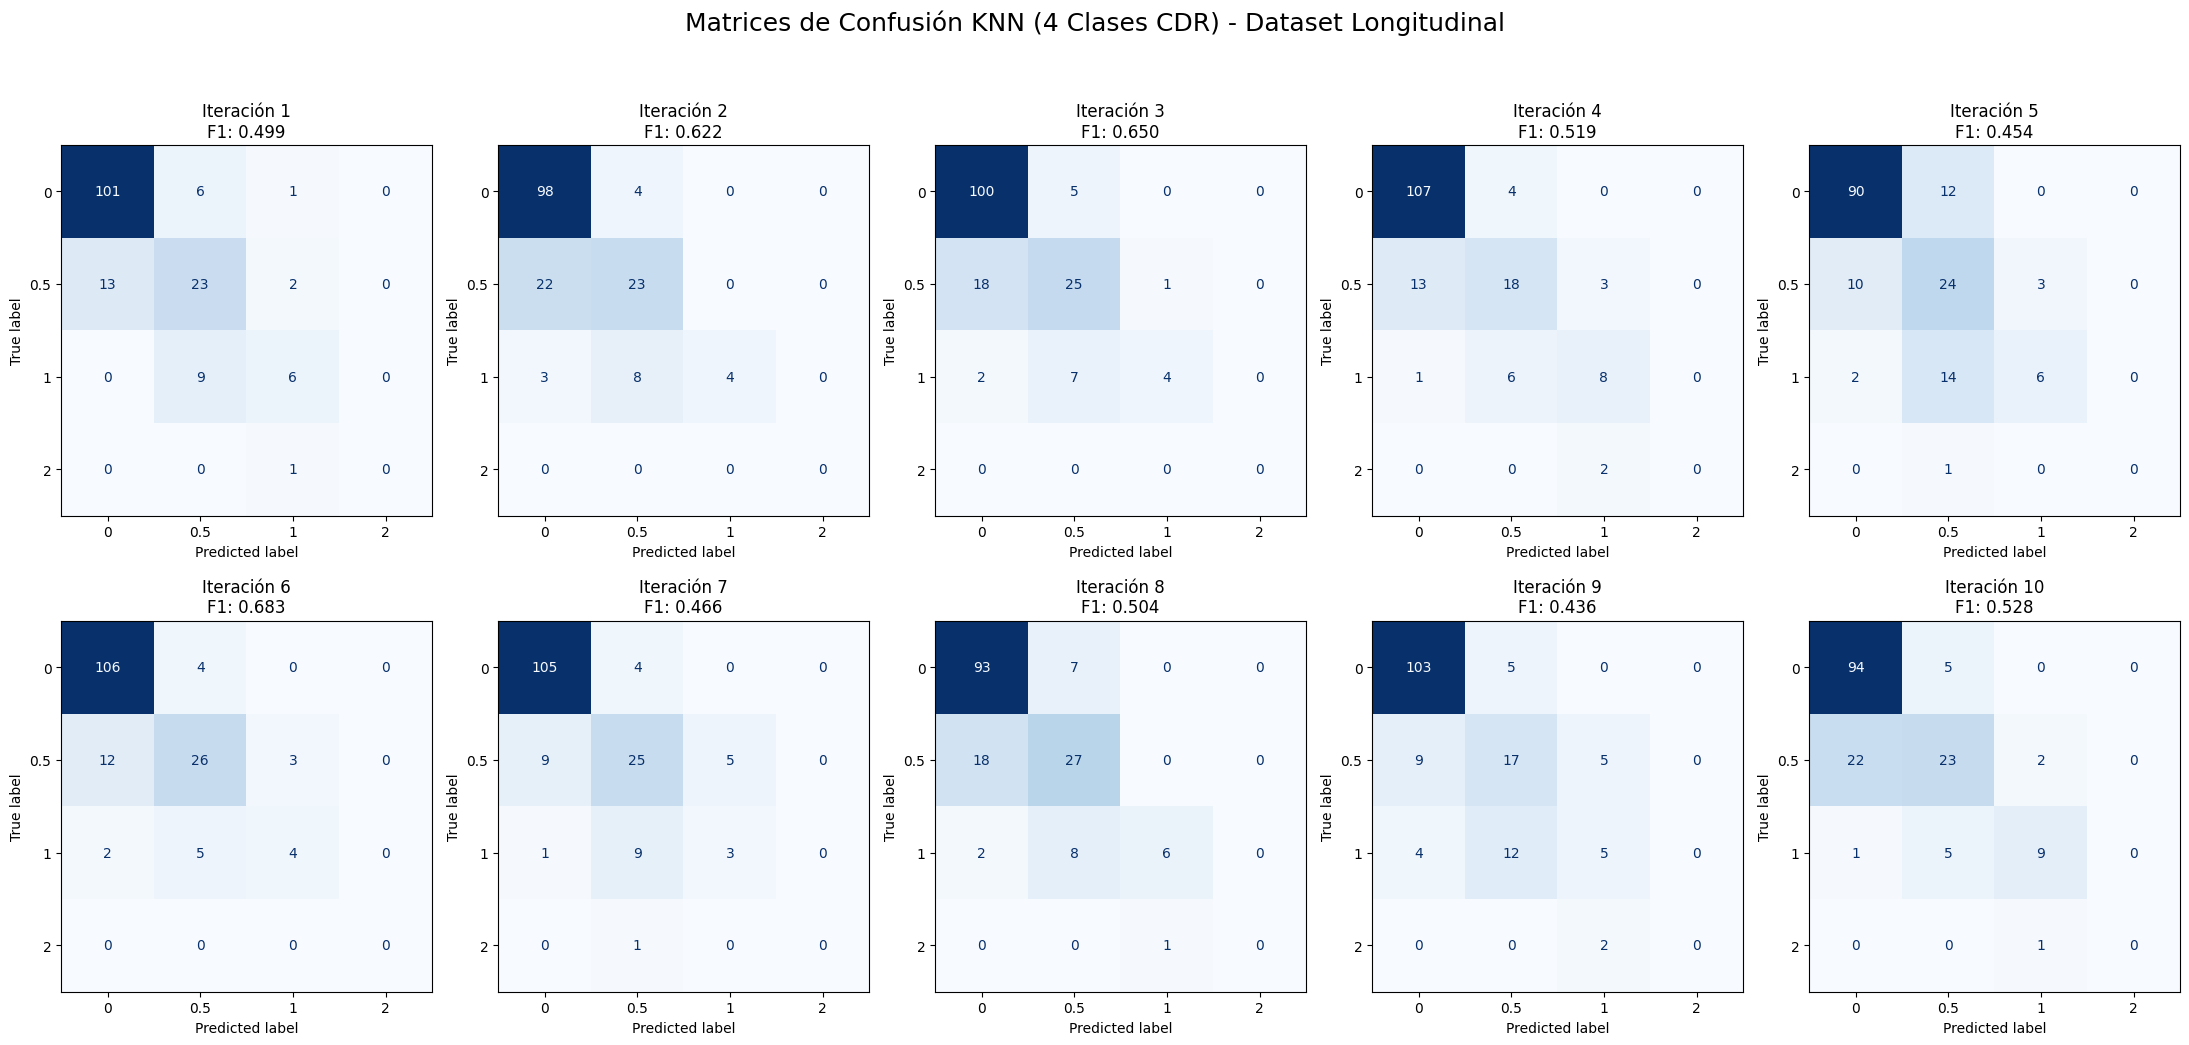


Métrica                   | Promedio ± DE            
-------------------------------------------------------
Accuracy                  | 0.7920 ± 0.0282
Precision (Macro)         | 0.5960 ± 0.1227
Recall (Macro)            | 0.5165 ± 0.0696
F1-score (Macro)          | 0.5362 ± 0.0816
AUC (Macro)               | 0.8265 ± 0.0520


In [46]:
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(Xdf)

# 2. Configuración Experimental (10 Validaciones 80/20)
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
fig, axes = plt.subplots(2, 5, figsize=(22, 11))
axes = axes.flatten()

print("Iniciando validaciones independientes...")

for i in range(10):
    # Partición aleatoria 80/20 única por iteración [2]
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, ydf, test_size=0.2, random_state=i
    )
    
    # 3. Escalamiento: Obligatorio para KNN (Sección 11.1 de la guía) [1, 3]
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # 4. Entrenamiento Modelo KNN (k=5 como base)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_s, y_train)
    y_pred = knn.predict(X_test_s)
    y_proba = knn.predict_proba(X_test_s) # Necesario para AUC
    
    # 5. Registro de Métricas (Promedio Macro por desbalance) [4, 5]
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
    results['rec'].append(recall_score(y_test, y_pred, average='macro', zero_division=0))
    results['f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))
    
    # Cálculo de AUC Multiclase (One-vs-Rest)
    # Binarizamos y_test usando las etiquetas de texto
    y_test_bin = label_binarize(y_test, classes=clases_str)
    try:
        results['auc'].append(roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro'))
    except ValueError:
        results['auc'].append(np.nan) # Manejo si una clase no aparece en el set de prueba
    
    # 6. Generación del Grid de Matrices de Confusión
    # Ahora 'y_test', 'y_pred' y 'clases_str' son todos strings, eliminando el TypeError
    cm = confusion_matrix(y_test, y_pred, labels=clases_str)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '0.5', '1', '2'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Iteración {i+1}\nF1: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión KNN (4 Clases CDR) - Dataset Longitudinal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 7. Reporte Final de Desempeño (Media ± DE) [6]
print("\n" + "="*55)
print(f"{'Métrica':<25} | {'Promedio ± DE':<25}")
print("-" * 55)
print(f"{'Accuracy':<25} | {np.mean(results['acc']):.4f} ± {np.std(results['acc']):.4f}")
print(f"{'Precision (Macro)':<25} | {np.mean(results['prec']):.4f} ± {np.std(results['prec']):.4f}")
print(f"{'Recall (Macro)':<25} | {np.mean(results['rec']):.4f} ± {np.std(results['rec']):.4f}")
print(f"{'F1-score (Macro)':<25} | {np.mean(results['f1']):.4f} ± {np.std(results['f1']):.4f}")
print(f"{'AUC (Macro)':<25} | {np.nanmean(results['auc']):.4f} ± {np.nanstd(results['auc']):.4f}")
print("="*55)
